In [185]:
import numpy as np
import pandas as pd
from scipy.signal import firwin2, filtfilt
import matplotlib.pyplot as plt
import matplotlib as mpl
import librosa
import librosa.display
import IPython.display as ipd
import soundfile as sf
from scipy.signal import freqz
from scipy.interpolate import interp1d

#Data input

In [186]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [187]:
!ls '/content/drive/MyDrive/Animals2.csv'

/content/drive/MyDrive/Animals2.csv


In [188]:
csv_bestand = "/content/drive/MyDrive/Animals2.csv"

#Interpolatie

In [218]:
# CSV inlezen
df = pd.read_csv(
    csv_bestand,
    sep=";",
    encoding="latin1",
    skiprows=1
)

df.columns = df.columns.str.strip().str.lower()
# Lijst van alle unieke dieren tonen
alle_dieren_unique = df["species"].unique()
print("Dieren in het bestand:")
for dier in alle_dieren_unique:
    print("- ", dier.lower())

print("\nAantal dieren:", len(alle_dieren_unique))
gekozen_dier = input("Geef het gewenste dier in: ").strip().lower()

Dieren in het bestand:
-  microtus ochrogaster
-  cavia porcellus
-  lithobates catesbeianus
-  myotis lucifugus
-  equus caballus
-  columba livia domestica
-  procyon lotor
-  corvus brachyrhynchos
-  phyllostomus hastatus
-  eptesicus fuscus
-  myotis lucifugus
-  rousettus aegyptiacus
-  rhinolophus ferrumequinum
-  erebia manto
-  rangifer tarandus
-  bos taurus
-  felis catus
-  canis lupus familiaris
-  sturnus vulgaris
-  hyla cinerea
-  cycnia tenera
-  tyto alba
-  parus major
-  oryctolagus cuniculus
-  gryllus texensis
-  ormia ochracea
-  asio otus

Aantal dieren: 27
Geef het gewenste dier in: asio otus


In [190]:
alle_dieren_unique = df["species"].unique() # Ensure alle_dieren_unique is defined here

if not gekozen_dier or gekozen_dier not in alle_dieren_unique:
    print(f"Ongeldige of geen selectie voor dier: '{gekozen_dier}'. Kies een van de volgende: {', '.join(alle_dieren_unique)}")
    raise ValueError("Geen geldig dier geselecteerd.")

# Filter en schoonmaken
dier_df = df[df["species"] == gekozen_dier].copy()
dier_df["freq"] = dier_df["freq"].astype(str).str.replace(',', '.').astype(float)
dier_df["threshold_db_mean"] = dier_df["threshold_db_mean"].astype(str).str.replace(',', '.').astype(float)

# Handle frequency units (Hz or kHz)
if 'dimension' in dier_df.columns:
    dier_df['dimension'] = dier_df['dimension'].astype(str).str.strip().str.lower()
    is_khz = dier_df['dimension'] == 'khz'
    dier_df.loc[is_khz, 'freq'] = dier_df.loc[is_khz, 'freq'] * 1000

dier_df = dier_df.dropna(subset=["freq", "threshold_db_mean"])

# Handle duplicate frequencies by taking the mean of threshold_db_mean
dier_df = dier_df.groupby("freq")["threshold_db_mean"].mean().reset_index()

dier_df = dier_df.sort_values(by="freq")

# Ensure there's data after filtering
if dier_df.empty:
    print(f"Geen data gevonden voor het gekozen dier: {gekozen_dier}. Controleer de invoer of de dataset.")
    raise ValueError("Geen data voor gekozen dier.")

dier_min = dier_df["freq"].min()
dier_max = dier_df["freq"].max()

# Best fit curve met cubic spline interpolatie
# Check if dier_df has enough data points for cubic spline
if len(dier_df) < 4: # Changed from 2 to 4 for cubic spline
    print(f"Niet genoeg data punten ({len(dier_df)}) voor {gekozen_dier} om een cubic spline te fitten. Kies een ander dier.")
    raise ValueError("Niet genoeg data punten.")

cubic_spline_function = interp1d(
    np.log10(dier_df["freq"]),
    dier_df["threshold_db_mean"],
    kind='cubic',
    bounds_error=False,
    fill_value="extrapolate"
)

# Maak fijne x-waarden voor een vloeiende curve (logaritmische schaal)
freq_interp = np.logspace(
    np.log10(dier_df["freq"].min()),
    np.log10(dier_df["freq"].max()),
    500
)
threshold_best_fit = cubic_spline_function(np.log10(freq_interp))

In [191]:
def show_treshold_curve(dier_df, freq_interp, threshold_best_fit):
  # Plot originele meetpunten + best fit curve
  label = "Best Fit Curve (Cubic Spline Interpolatie)"
  plt.figure()
  plt.plot(freq_interp, threshold_best_fit, label=label, color="blue")
  plt.scatter(dier_df["freq"], dier_df["threshold_db_mean"], color="red", zorder=5, label="Meetpunten")
  plt.xscale("log")
  plt.xlabel("Frequentie (Hz)")
  plt.ylabel("dB drempelwaarde (dB_mean)")
  plt.ylim(dier_df["threshold_db_mean"].min() - 5, dier_df["threshold_db_mean"].max() + 5) # Vergroot y-as grenzen
  plt.title(f"Gehoordrempel vs Frequentie voor {gekozen_dier}")
  plt.grid(True, which="both", ls="--", lw=0.5)
  plt.legend()
  plt.show()

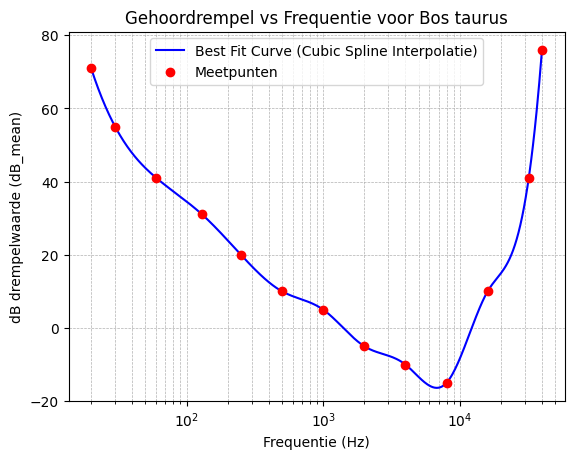

In [192]:
show_treshold_curve(dier_df, freq_interp, threshold_best_fit)

# Weging

In [193]:
third_octave_freqs = [
    20, 25, 31.5, 40, 50, 63, 80,
    100, 125, 160, 200, 250, 315, 400,
    500, 630, 800, 1000, 1250, 1600,
    2000, 2500, 3150, 4000, 5000, 6300,
    8000, 10000, 12500, 16000, 20000, 25000, 31500, 40000
]

interpolated_db_values = cubic_spline_function(np.log10(third_octave_freqs))

interpolated_results = []

for i, freq in enumerate(third_octave_freqs):
  if freq <= dier_max and freq >= dier_min:
    interpolated_results.append({
        'Animal': gekozen_dier,
        'Frequency (Hz)': freq,
        'Interpolated dB': interpolated_db_values[i]
    })

interpolated_df = pd.DataFrame(interpolated_results)

def show_weighing(interpolated_df):
  plt.figure(figsize=(10, 5))

  plt.semilogx(
      interpolated_df["Frequency (Hz)"],
      interpolated_df["Interpolated dB"],
      marker="o",
      label="Animal Calculated Treshold",
      linestyle="None"
  )

  plt.xlabel("Frequency (Hz)")
  plt.ylabel("dB Treshold")
  plt.grid(True, which="both")
  plt.legend()
  plt.show()

In [194]:
display(interpolated_df)

,Animal,Frequency (Hz),Interpolated dB
0,Bos taurus,20.0,71.000000
1,Bos taurus,25.0,61.216719
2,Bos taurus,31.5,53.569359
3,Bos taurus,40.0,47.744617
4,Bos taurus,50.0,43.683172
5,Bos taurus,63.0,40.341208
6,Bos taurus,80.0,37.309309
7,Bos taurus,100.0,34.547347
8,Bos taurus,125.0,31.567259
9,Bos taurus,160.0,27.747061


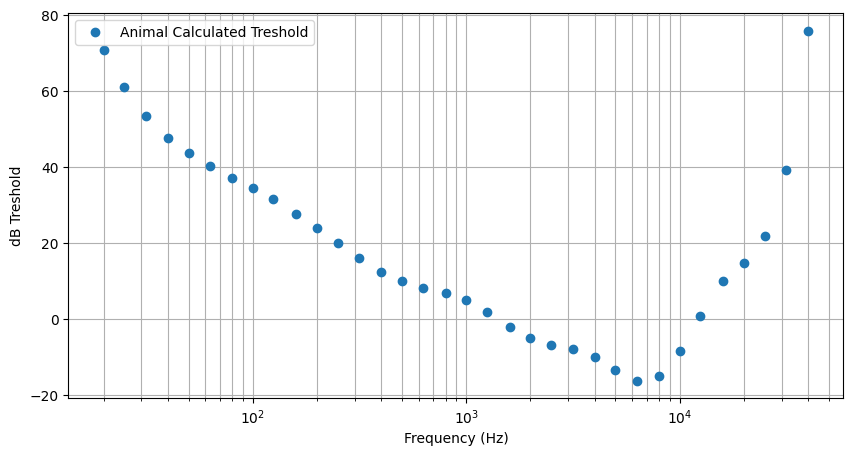

In [195]:
show_weighing(interpolated_df)

#Audiofile laden en bekijken
luister:
`ipd.Audio(audiofile)`

data:
`show_audio(audio, sr)`

spectogram:
`show_spectrogram(audio, sr)`

In [196]:
audiofile = "/content/drive/MyDrive/AudioMoth/20260319_111400.WAV"
#audiofile = input("Geef het audio bestand in: ")

In [197]:
audio, sr = librosa.load(audiofile, sr=None)

def show_audio(audio, sr, title = None):
  t = np.arange(len(audio)) / sr
  pd.Series(audio, index = t).plot(title = title, ylabel = 'Amplitude', xlabel = 'Time',figsize=(10, 5))
  plt.show()

def show_spectrogram(audio, sr, title = None, vmin=None, vmax=None):
  S = librosa.amplitude_to_db(np.abs(librosa.stft(audio)))
  fig, ax = plt.subplots(figsize = (10, 5))
  img1 = librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='log', ax=ax, cmap = 'plasma', fmin=400, fmax=40000, vmin=vmin, vmax=vmax)
  fig.colorbar(img1, ax=ax, format="%+2.0f dB")
  plt.title(title)
  plt.show()

In [198]:
#show_audio(audio, sr)

In [199]:
#show_spectrogram(audio, sr)

In [200]:
#ipd.Audio(audiofile)

#Equalizer maken

In [201]:
def build_equalizer(interpolated_df, fs=44100, numtaps=4096): # Geeft df met gains in dB per freq

  animal_df = interpolated_df.copy()

  human_thresholds = {
      20: 78.5,
      25: 68.7,
      31.5: 59.5,
      40: 51.1,
      50: 44.0,
      63: 37.5,
      80: 31.5,
      100: 26.5,
      125: 22.1,
      160: 17.9,
      200: 14.4,
      250: 11.4,
      315: 8.6,
      400: 6.2,
      500: 4.4,
      630: 3.0,
      800: 2.2,
      1000: 2.4,
      1250: 3.5,
      1600: 1.7,
      2000: -1.3,
      2500: -4.2,
      3150: -6.0,
      4000: -5.4,
      5000: -1.5,
      6300: 6.0,
      8000: 12.6,
      10000: 13.9,
      12500: 12.3,
      16000: 18.4,
      20000: 40.2,
      25000: 55.0,
      31500: 75.0,
      40000: 95.0
  }

  animal_df.loc[:, "human"] = animal_df["Frequency (Hz)"].map(human_thresholds)

  animal_df.loc[:, "gain"] = (
      animal_df["human"] - animal_df["Interpolated dB"]
  )

  return animal_df

In [202]:
animal_df = build_equalizer(interpolated_df)

#Equalizer tonen

In [203]:
def show_equalizer(animal_df, title = None):
  plt.figure(figsize=(10, 5))

  # Equalizer Curve
  plt.semilogx(
      animal_df["Frequency (Hz)"],
      animal_df["gain"],
      label="Equalizer Curve",
      marker="o",
      linestyle="None"
  )

  # Human threshold
  plt.semilogx(
      animal_df["Frequency (Hz)"],
      animal_df["human"],
      marker="o",
      label="Human Threshold",
      linestyle="None"
  )

  # Animal threshold
  plt.semilogx(
      animal_df["Frequency (Hz)"],
      animal_df["Interpolated dB"],
      marker="o",
      label="Animal Threshold",
      linestyle="None"
  )

  plt.axhline(0, linestyle="--")

  plt.xlabel("Frequency (Hz)")
  plt.ylabel("dB (Gain/Treshold)")
  plt.title(title)
  plt.grid(True, which="both")

  plt.legend()

  plt.show()

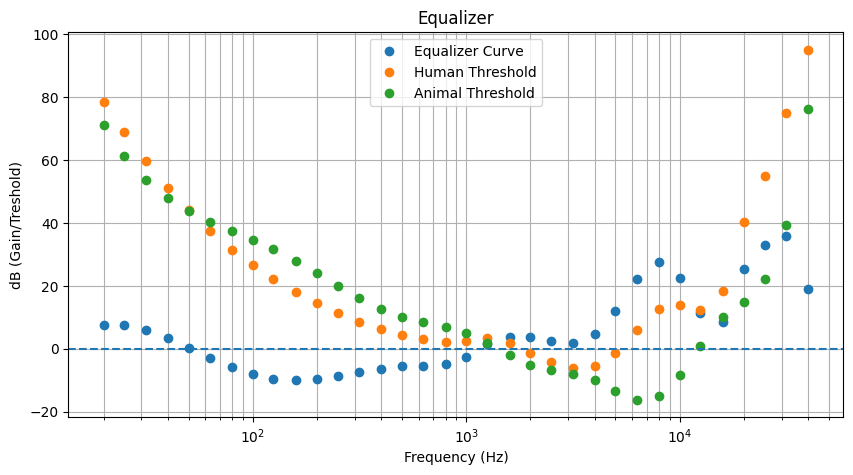

In [204]:
show_equalizer(animal_df, title = 'Equalizer')

#Equalizer toepassen

In [205]:
def apply_equalizer(animal_df, audio): # Geeft gefilterde audio

  third_octave_freqs = animal_df["Frequency (Hz)"]
  third_octave_gains = animal_df["gain"]
  stft = librosa.stft(audio)
  freqs = librosa.fft_frequencies(sr=sr)

  interp = interp1d(
      third_octave_freqs,
      third_octave_gains,
      bounds_error=False,
      fill_value = 0
  )

  gain_db = interp(freqs)
  gain_linear = 10 ** (gain_db / 20)

  stft_eq = stft * gain_linear[:, np.newaxis]
  audio_eq = librosa.istft(stft_eq)

  return audio_eq

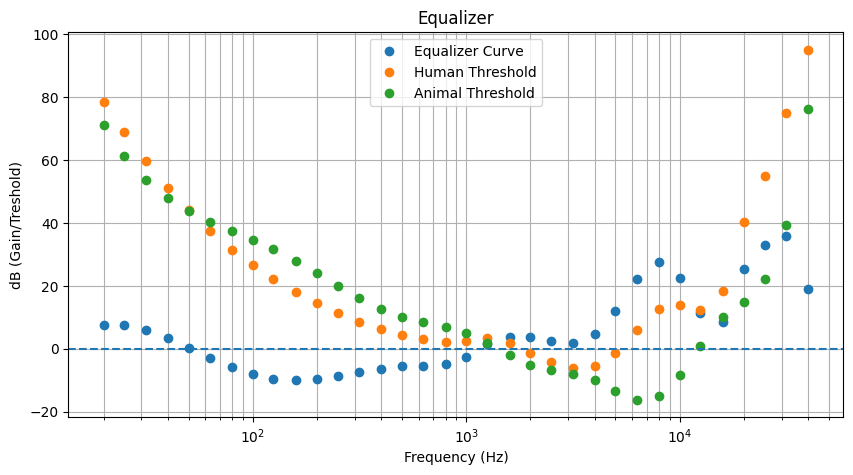

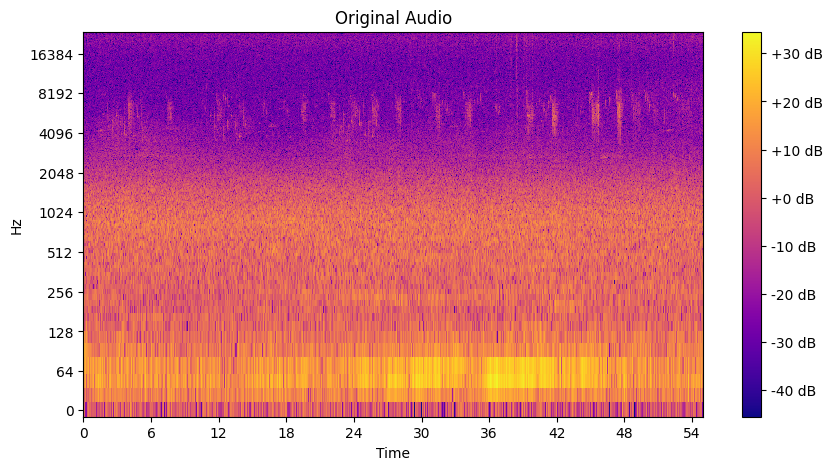

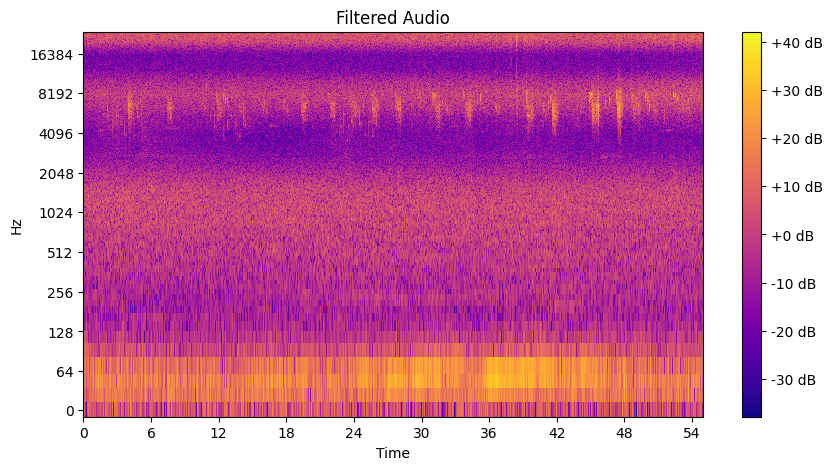

In [206]:
filtered_audio = apply_equalizer(animal_df, audio)
show_equalizer(animal_df, title = 'Equalizer')
show_spectrogram(audio, sr, title = 'Original Audio')
show_spectrogram(filtered_audio, sr, title = 'Filtered Audio')

In [207]:
ipd.Audio(filtered_audio, rate = sr)

Output hidden; open in https://colab.research.google.com to view.

#Inverse Filter (controle)

In [208]:
def show_inv_equalizer(animal_df):
  plt.figure(figsize=(10, 5))

  # Equalizer Curve
  plt.semilogx(
      animal_df["Frequency (Hz)"],
      animal_df["gain"],
      label="Equalizer Curve",
      marker="o",
      linestyle="None"
  )

  # Inverse Equalizer Curve
  plt.semilogx(
      animal_df["Frequency (Hz)"],
      -animal_df["gain"],
      label="Inverse Equalizer Curve",
      marker="o",
      linestyle="None"
  )

  plt.axhline(0, linestyle="--")

  plt.xlabel("Frequency (Hz)")
  plt.ylabel("dB Gain")
  plt.title(f"Equalizer Curve")
  plt.grid(True, which="both")

  plt.legend()

  plt.show()

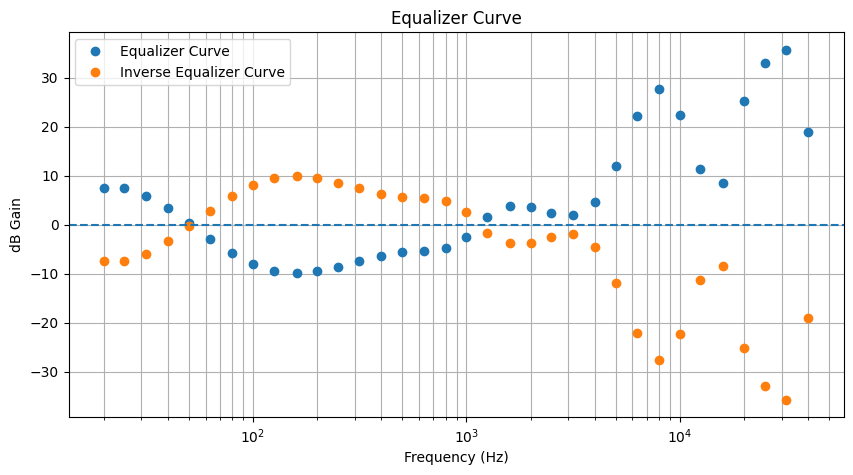

In [209]:
show_inv_equalizer(animal_df)

In [210]:
def apply_inv_equalizer(animal_df, audio):
  third_octave_freqs = animal_df["Frequency (Hz)"]
  third_octave_gains = -animal_df["gain"]
  stft = librosa.stft(audio)
  freqs = librosa.fft_frequencies(sr=sr)

  interp = interp1d(
      third_octave_freqs,
      third_octave_gains,
      bounds_error=False,
      fill_value = 0
  )

  gain_db = interp(freqs)
  gain_linear = 10 ** (gain_db / 20)

  stft_eq = stft * gain_linear[:, np.newaxis]
  audio_eq = librosa.istft(stft_eq)

  return audio_eq

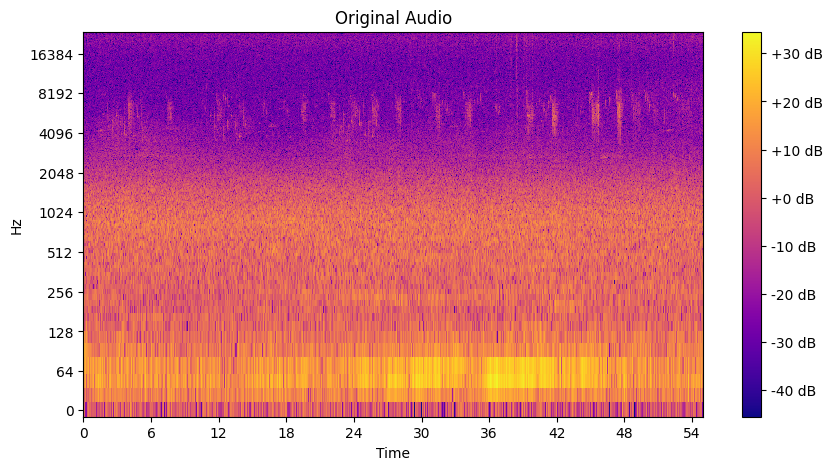

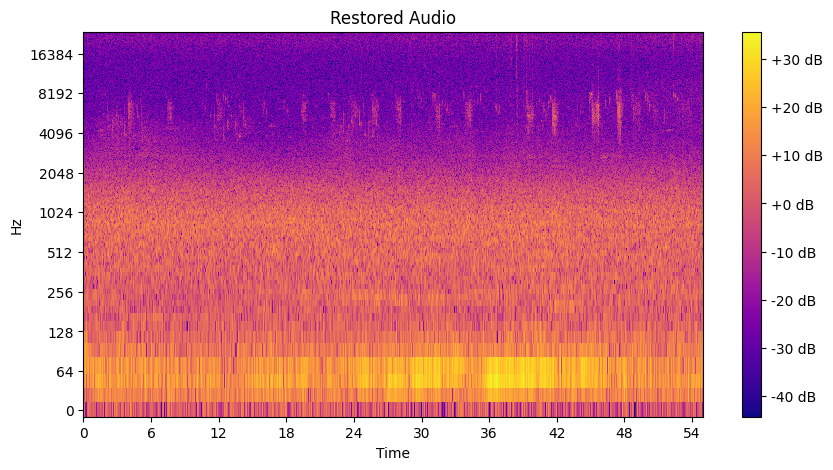

In [211]:
audio2 = apply_inv_equalizer(animal_df, apply_equalizer(animal_df, audio))
show_spectrogram(audio, sr, title = 'Original Audio')
show_spectrogram(audio2, sr, title = 'Restored Audio')